Data shape: (70000, 784)
Training the classifier...

Model Accuracy: 93.77%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1726
           1       0.96      0.99      0.97      1969
           2       0.91      0.93      0.92      1748
           3       0.91      0.92      0.91      1785
           4       0.93      0.95      0.94      1706
           5       0.91      0.90      0.91      1578
           6       0.96      0.95      0.95      1719
           7       0.96      0.95      0.95      1823
           8       0.94      0.89      0.91      1706
           9       0.94      0.91      0.92      1740

    accuracy                           0.94     17500
   macro avg       0.94      0.94      0.94     17500
weighted avg       0.94      0.94      0.94     17500



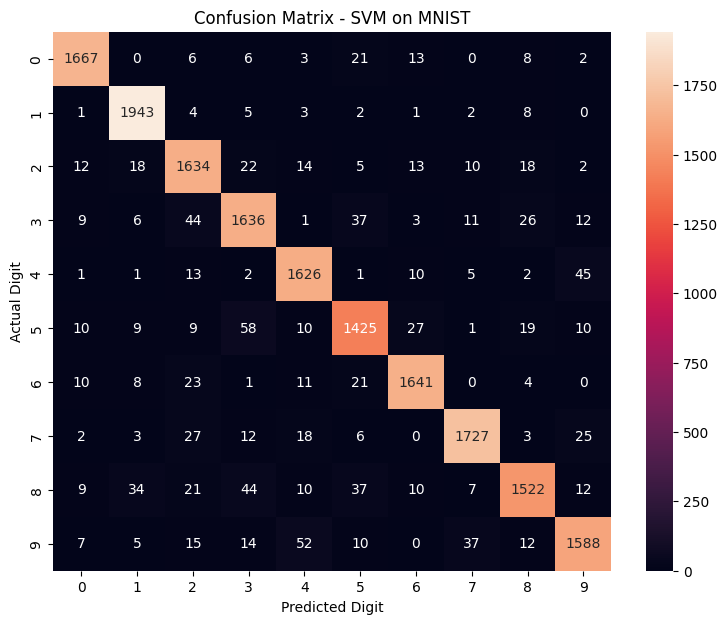

In [1]:
# -----------------------------
# MNIST Digit Classification using SVM
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: Load Dataset
print("Downloading MNIST dataset...")
dataset = fetch_openml(name="mnist_784", version=1, as_frame=False)

data = dataset.data
target = dataset.target.astype(np.int32)

print("Data shape:", data.shape)

# Step 2: Normalize Features using MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Step 3: Split into Train & Test
X_train, X_test, y_train, y_test = train_test_split(
    data_scaled,
    target,
    test_size=0.25,   # slightly different split
    random_state=0,
    stratify=target
)

# Step 4: Create and Train Model
classifier = SVC(kernel="linear", C=1.0)
print("Training the classifier...")
classifier.fit(X_train, y_train)

# Step 5: Prediction
predicted = classifier.predict(X_test)

# Step 6: Evaluation
accuracy = accuracy_score(y_test, predicted)
print(f"\nModel Accuracy: {accuracy*100:.2f}%")

print("\nDetailed Classification Report:")
print(classification_report(y_test, predicted))

cm = confusion_matrix(y_test, predicted)

# Plot Confusion Matrix
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - SVM on MNIST")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.show()
